# Lab 8: Dimensionality Reduction

**DCS 357A / NRSC 357A / PSYC 357A — Computational Neuroscience**

---

We've come across the idea of **dimensionality** an awful lot in this class. As you've surely come to appreciate, the dimensionality of a dataset is just the number of measured features for each data point. Dimensionality **reduction** then, must refer to the act of throwing some features away, right? 

*Kind of*, but let's think it through a bit more carefully. One kind of trivial dimensionality reduction would just be throwing away features that don't matter, and which are identical across all samples. If you have a bunch of 20 x 20 thumbnail images, but your phone is busted and all the pixels on the lower half of your camera are dead, then there's probably no sense in hanging on to all 400 pixels. You only need to store the top half of the data (200 pixels). Dimensionality reduced! 

That feels a bit unsatisfying though. We're actually after something more subtle than just throwing away half of the pixels, or a third of the 20,000 genes, or whatever. We want to first see if there's a way we can represent our data in a less "expensive" way. That is, find a compressed vesion of it that describes its fundamental structure, without losing too much information in the process. If you've ever looked at file sizes of photos before and after compression, you appreciated this directly. The file might be a tenth of the size of the original, and yet.... apart from a little bit of lost resolution, it still looks pretty damn good!

The fundamental trick we need to pull off is stop thinking about our data in a single-feature-at-a-time way, and start thinking about it in terms of **groups of related features**, or **feature patterns**. Our friend Mr. Potato head is here to help: 

## The Problem

A modern Neuropixels probe records from **384 channels** simultaneously. A two-photon calcium imaging session might capture **10,000 neurons**. Your olfactory bulb dataset from Lab 4 had 59 features. The digits you classified in Lab 5 lived in 64 dimensions.

How do you make sense of data that lives in hundreds — or thousands — of dimensions?

You can't plot 10,000 axes. You can't eyeball a 384-dimensional scatter plot. And it turns out that in very high dimensions, strange things happen: distances between points all start to look the same, and most of the space is empty. This is sometimes called the **curse of dimensionality**.

The good news is that neural data is usually much simpler than it looks. When you record from 10,000 neurons, they aren't all doing independent things — they're coordinated, correlated, and constrained. The *effective* dimensionality of the data is much lower than the *measured* dimensionality. **Dimensionality reduction** is a family of techniques for finding that low-dimensional structure.

In Lab 7, we used PCA to squash our data down to 2D so we could visualize clusters. Today we'll understand what PCA is actually doing, and meet three other methods that each bring something different to the table.

## Goals for today

1. Understand what dimensionality reduction means geometrically — projections, rotations, finding the axes that matter
2. Use **PCA** to find the directions of greatest variance in data
3. Discover nonlinear structure with **t-SNE** and **UMAP**
4. Extract interpretable, additive parts with **NMF**
5. Apply these methods to real and simulated neural data
6. Combine dimensionality reduction with clustering (connecting back to Lab 7)

In [1]:
# === Setup: run this cell first ===
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.decomposition import PCA, NMF
from sklearn.manifold import TSNE
from sklearn.preprocessing import StandardScaler, MinMaxScaler
from sklearn.datasets import load_iris, load_digits
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
import time
import warnings
warnings.filterwarnings('ignore')

# Install and import UMAP
!pip install -q umap-learn
import umap

np.random.seed(357)
%matplotlib inline
plt.rcParams['figure.dpi'] = 100
print('All imports successful!')

All imports successful!


> **Note on runtime:** Some cells in this lab (especially t-SNE and UMAP) take 10–30 seconds to run. That's normal — these algorithms are doing a lot of work. If a cell seems to hang, give it a minute before worrying.

---
## Part 1: PCA — Finding the Axes That Matter

Before we touch neural data, let's build intuition with something we can **see**.

PCA (Principal Component Analysis) finds the directions along which your data varies the most. To understand what that means, let's start with data that lives in just 2 dimensions, so we can watch PCA work.

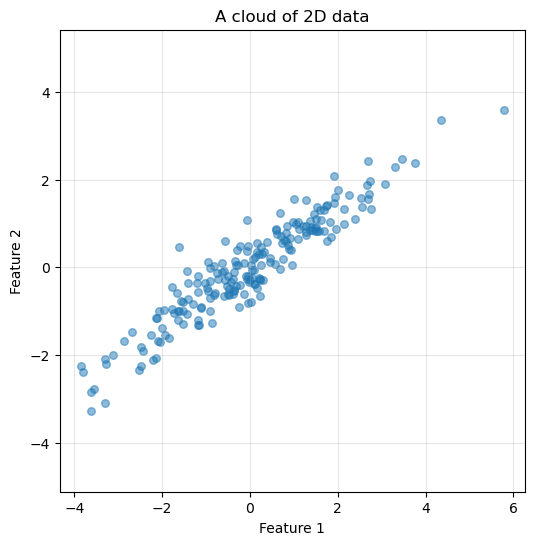

In [2]:
# Generate a tilted cloud of 2D points
np.random.seed(42)
cov = [[3, 2], [2, 1.5]]  # correlated features
data_2d = np.random.multivariate_normal([0, 0], cov, 200)

plt.figure(figsize=(6, 6))
plt.scatter(data_2d[:, 0], data_2d[:, 1], alpha=0.5, s=30)
plt.xlabel('Feature 1')
plt.ylabel('Feature 2')
plt.title('A cloud of 2D data')
plt.axis('equal')
plt.grid(True, alpha=0.3)
plt.show()

This cloud is an ellipse tilted at an angle. PCA is going to find the **long axis** and the **short axis** of this ellipse.

- The long axis is the direction of greatest spread — that's **PC1** (the first principal component).
- The short axis, perpendicular to it, is **PC2**.

Let's fit PCA and see those axes.

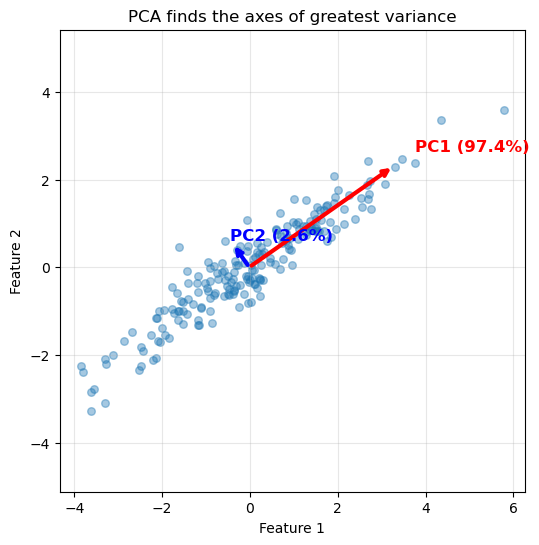

In [3]:
# Fit PCA and overlay the principal component directions
pca_2d = PCA(n_components=2)
pca_2d.fit(data_2d)

plt.figure(figsize=(6, 6))
plt.scatter(data_2d[:, 0], data_2d[:, 1], alpha=0.4, s=30)

# Draw arrows for each PC, scaled by the amount of variance they explain
mean = pca_2d.mean_
colors = ['red', 'blue']
labels = ['PC1', 'PC2']
for i, (comp, var) in enumerate(zip(pca_2d.components_, pca_2d.explained_variance_)):
    arrow = comp * np.sqrt(var) * 2  # scale for visibility
    plt.annotate('', xy=mean + arrow, xytext=mean,
                 arrowprops=dict(arrowstyle='->', color=colors[i], lw=3))
    plt.text(mean[0] + arrow[0]*1.15, mean[1] + arrow[1]*1.15,
             f'{labels[i]} ({pca_2d.explained_variance_ratio_[i]:.1%})',
             fontsize=12, fontweight='bold', color=colors[i])

plt.xlabel('Feature 1')
plt.ylabel('Feature 2')
plt.title('PCA finds the axes of greatest variance')
plt.axis('equal')
plt.grid(True, alpha=0.3)
plt.show()

The **red arrow** (PC1) points along the direction of greatest spread. The **blue arrow** (PC2) is perpendicular — it captures whatever variation is left. The percentages tell you how much of the total variance each axis explains.

Now here's the key move: what if we **project** all the points onto just the PC1 line? We go from 2D to 1D, keeping only the direction that matters most.

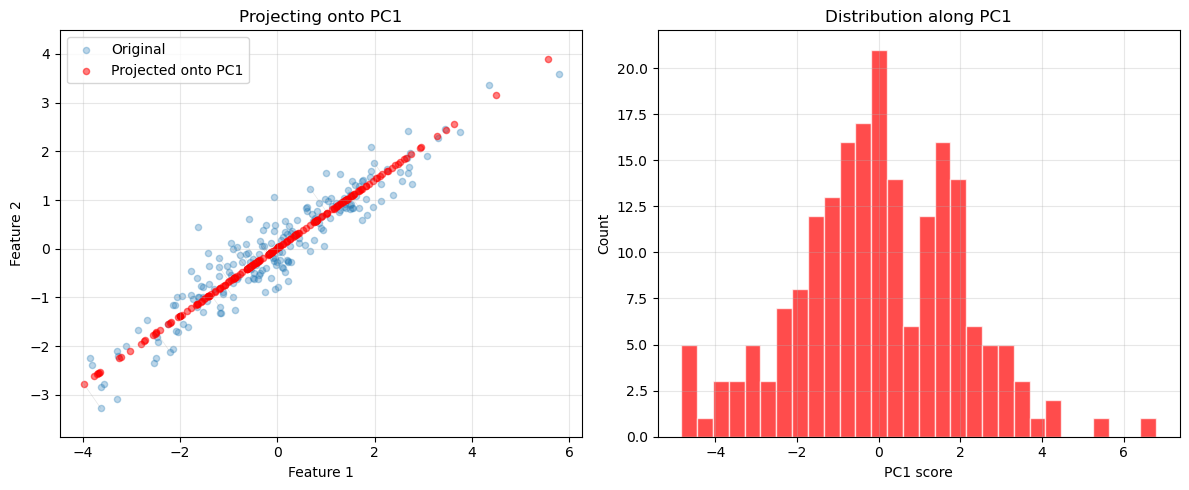

In [4]:
# Project the 2D data onto PC1 (dimensionality reduction: 2D -> 1D)
scores = pca_2d.transform(data_2d)
projected = pca_2d.inverse_transform(np.column_stack([scores[:, 0], np.zeros(len(scores))]))

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Left: show the projection lines
axes[0].scatter(data_2d[:, 0], data_2d[:, 1], alpha=0.3, s=20, label='Original')
axes[0].scatter(projected[:, 0], projected[:, 1], alpha=0.5, s=20, color='red', label='Projected onto PC1')
for i in range(0, len(data_2d), 5):  # draw some projection lines
    axes[0].plot([data_2d[i, 0], projected[i, 0]],
                 [data_2d[i, 1], projected[i, 1]], 'gray', alpha=0.2, lw=0.5)
axes[0].set_xlabel('Feature 1')
axes[0].set_ylabel('Feature 2')
axes[0].set_title('Projecting onto PC1')
axes[0].axis('equal')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Right: the 1D distribution of PC1 scores
axes[1].hist(scores[:, 0], bins=30, color='red', alpha=0.7, edgecolor='white')
axes[1].set_xlabel('PC1 score')
axes[1].set_ylabel('Count')
axes[1].set_title('Distribution along PC1')
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

That's dimensionality reduction in its simplest form. We took 2D data and **projected** it onto 1D — the single direction that preserves the most spread. We lost some information (the PC2 variation), but we kept the main story.

Now let's try it with real data.

### ✏️ Exercise 1.1: PCA on the Iris dataset

The Iris dataset has 4 features (sepal length, sepal width, petal length, petal width) and 3 species. Apply PCA to reduce it to 2D and make a scatter plot colored by species.

**Steps:**
1. Load the Iris data (done for you)
2. Standardize the features with `StandardScaler` — fit and transform
3. Fit `PCA(n_components=2)` on the standardized data
4. Transform the data and make a scatter plot, coloring by `iris.target`

In [5]:
# Load Iris
iris = load_iris()
X_iris = iris.data
y_iris = iris.target
print(f'Iris data shape: {X_iris.shape}')  # (150, 4)

# YOUR CODE HERE
# 1. Standardize: scaler = StandardScaler() ...
# 2. Fit PCA: pca_iris = PCA(n_components=2) ...
# 3. Transform: iris_pca = ...
# 4. Scatter plot: plt.scatter(..., c=y_iris, cmap='viridis') ...


Iris data shape: (150, 4)


### ✏️ Exercise 1.2: The Scree Plot

How many components do we actually need? A **scree plot** shows how much variance each PC explains.

Fit PCA with all 4 components. Make a **bar plot** of `explained_variance_ratio_` for each component. How much variance do the first 2 PCs capture together?

In [ ]:
# YOUR CODE HERE
# 1. Fit PCA with n_components=4 on the standardized Iris data
# 2. Bar plot of explained_variance_ratio_
# 3. Print the cumulative variance for 2 components


### ✏️ Exercise 1.3: Reflection

In your own words: why did we standardize the data before running PCA? What could go wrong if one feature is measured in millimeters and another in meters?

(Hint: think about which direction would have the most "variance.")

*Your answer here:*



---
## Part 2: PCA on High-Dimensional Data

4 dimensions was a nice warm-up, but neuroscience data is much bigger. Let's use the handwritten digits you worked with in Lab 5. Each image is 8x8 = **64 pixels**. That's 64 dimensions. Can PCA find the important structure?

Digits data shape: (1797, 64)


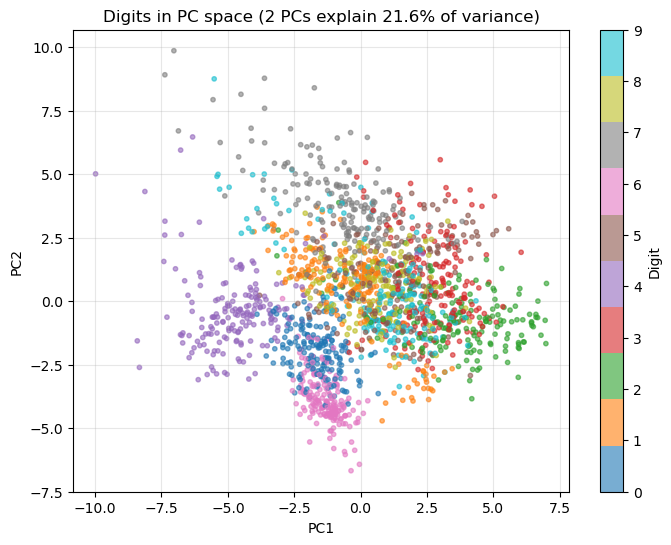

In [6]:
# Load digits (8x8 images, 10 classes)
digits = load_digits()
X_digits = digits.data
y_digits = digits.target
print(f'Digits data shape: {X_digits.shape}')  # (1797, 64)

# Standardize and apply PCA to 2D
scaler_digits = StandardScaler()
X_digits_scaled = scaler_digits.fit_transform(X_digits)

pca_digits_2d = PCA(n_components=2)
digits_2d = pca_digits_2d.fit_transform(X_digits_scaled)

plt.figure(figsize=(8, 6))
scatter = plt.scatter(digits_2d[:, 0], digits_2d[:, 1],
                      c=y_digits, cmap='tab10', s=10, alpha=0.6)
plt.colorbar(scatter, label='Digit')
plt.xlabel('PC1')
plt.ylabel('PC2')
plt.title(f'Digits in PC space (2 PCs explain {pca_digits_2d.explained_variance_ratio_.sum():.1%} of variance)')
plt.grid(True, alpha=0.3)
plt.show()

Not bad! PCA separates some digits (0 and 1 are far apart) but others overlap heavily. PCA is limited to **linear** projections — it can only rotate and squash the data. It can't bend or fold the space to untangle things. We'll come back to this limitation shortly.

But first: how many dimensions do the digits *actually* need?

### ✏️ Exercise 2.1: How many dimensions do digits need?

Fit PCA with all 64 components. Make a **cumulative variance plot** — the x-axis is the number of components, and the y-axis is the total variance explained by the first k components.

How many PCs do you need to capture **90%** of the variance? **95%**?

In [ ]:
# YOUR CODE HERE
# 1. Fit PCA(n_components=64) on X_digits_scaled
# 2. Compute cumulative variance: np.cumsum(pca.explained_variance_ratio_)
# 3. Plot cumulative variance vs. number of components
# 4. Add horizontal lines at 0.90 and 0.95
# 5. Print: how many PCs for 90%? for 95%?
#    Hint: np.argmax(cumvar >= 0.90) + 1


### Reconstruction: seeing what PCA keeps and loses

PCA lets you go backwards — reconstruct an approximation of the original image using only k components. Watch what happens as we increase k from 1 to 64:

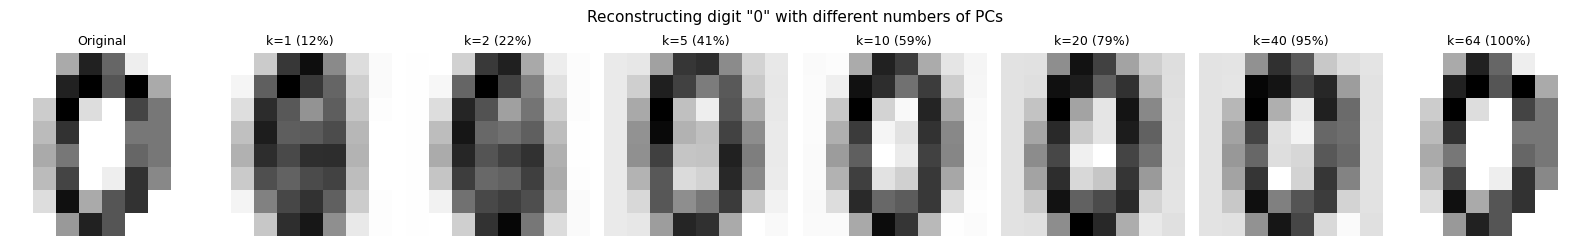

In [7]:
# Reconstruct a digit at different numbers of components
pca_full = PCA(n_components=64).fit(X_digits_scaled)
example_idx = 0  # pick one digit to reconstruct
original = X_digits[example_idx].reshape(8, 8)

k_values = [1, 2, 5, 10, 20, 40, 64]
fig, axes = plt.subplots(1, len(k_values) + 1, figsize=(16, 2.5))

axes[0].imshow(original, cmap='gray_r')
axes[0].set_title('Original', fontsize=9)
axes[0].axis('off')

for i, k in enumerate(k_values):
    # Keep only the first k components
    transformed = pca_full.transform(X_digits_scaled[example_idx:example_idx+1])
    truncated = np.zeros_like(transformed)
    truncated[0, :k] = transformed[0, :k]
    reconstructed = scaler_digits.inverse_transform(pca_full.inverse_transform(truncated))
    cumvar = pca_full.explained_variance_ratio_[:k].sum()

    axes[i+1].imshow(reconstructed.reshape(8, 8), cmap='gray_r')
    axes[i+1].set_title(f'k={k} ({cumvar:.0%})', fontsize=9)
    axes[i+1].axis('off')

fig.suptitle(f'Reconstructing digit "{digits.target[example_idx]}" with different numbers of PCs', fontsize=11)
plt.tight_layout()
plt.show()

With just 10 components (out of 64), the digit is already recognizable. That's dimensionality reduction doing its job: finding the essential structure and discarding the noise.

But PCA has a fundamental limitation: it can only find **linear** structure — straight axes, flat planes. What if the interesting patterns in your data live on a curved surface? Time for something nonlinear.

---
## Part 3: t-SNE — Preserving Local Neighborhoods

t-SNE (t-distributed Stochastic Neighbor Embedding) asks a fundamentally different question than PCA.

PCA asks: *"Which directions have the most variance?"*

t-SNE asks: *"Which points are neighbors in high-D, and can I place them as neighbors in 2D too?"*

It focuses on preserving **local structure** — nearby points stay nearby. This makes it extremely good at revealing clusters and groupings that PCA misses.

**Important warnings** about reading t-SNE plots:
1. The **axes are meaningless** — there's no "PC1" to interpret
2. **Distances between clusters** are meaningless — don't conclude that clusters that are close together are "more similar"
3. **Cluster sizes** are meaningless — t-SNE can inflate or shrink clusters
4. **Run it multiple times** — the layout changes each time; only the *groupings* are reliable

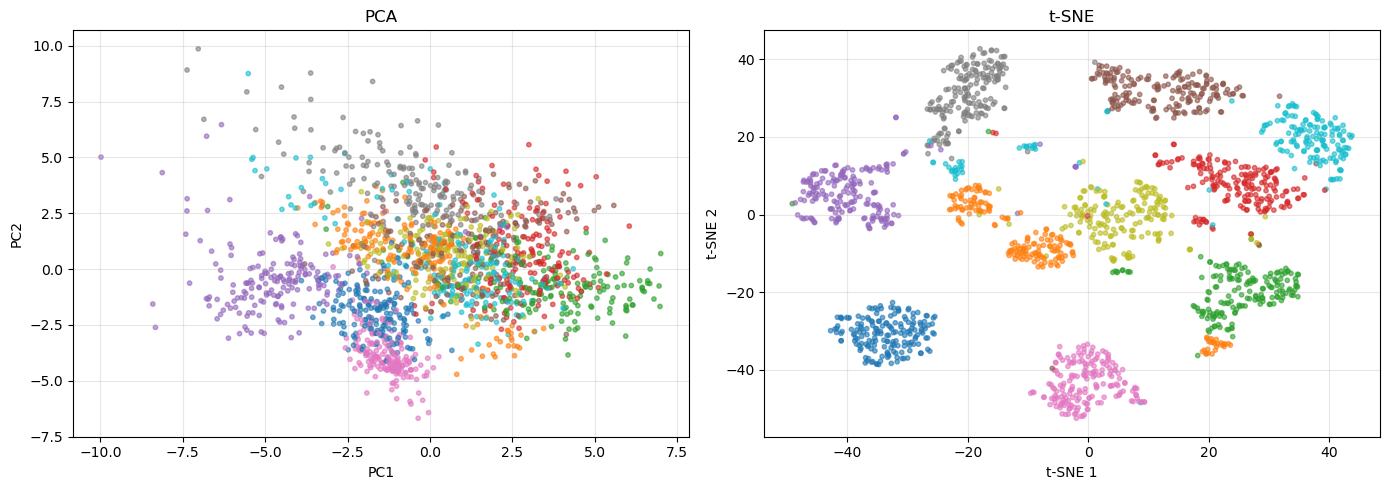

In [8]:
# t-SNE on digits
tsne = TSNE(n_components=2, perplexity=30, random_state=42)
digits_tsne = tsne.fit_transform(X_digits_scaled)

# Side-by-side: PCA vs t-SNE
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].scatter(digits_2d[:, 0], digits_2d[:, 1], c=y_digits, cmap='tab10', s=10, alpha=0.6)
axes[0].set_title('PCA')
axes[0].set_xlabel('PC1')
axes[0].set_ylabel('PC2')
axes[0].grid(True, alpha=0.3)

axes[1].scatter(digits_tsne[:, 0], digits_tsne[:, 1], c=y_digits, cmap='tab10', s=10, alpha=0.6)
axes[1].set_title('t-SNE')
axes[1].set_xlabel('t-SNE 1')
axes[1].set_ylabel('t-SNE 2')
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

Notice how the digit clusters are now much more clearly separated in the t-SNE plot. t-SNE "unfolded" the nonlinear structure that PCA couldn't capture.

But remember those warnings: the distances *between* clusters don't mean anything. Don't conclude that 3 and 8 are "more similar" just because their clusters happen to be close in this particular run.

### ✏️ Exercise 3.1: Exploring perplexity

The `perplexity` parameter controls how many neighbors t-SNE considers. It's roughly "how many nearby points should each point pay attention to?"

Try perplexity values of **5, 15, 30, 50, and 100**. Make a 1×5 grid of scatter plots (all colored by digit label). How does the visualization change?

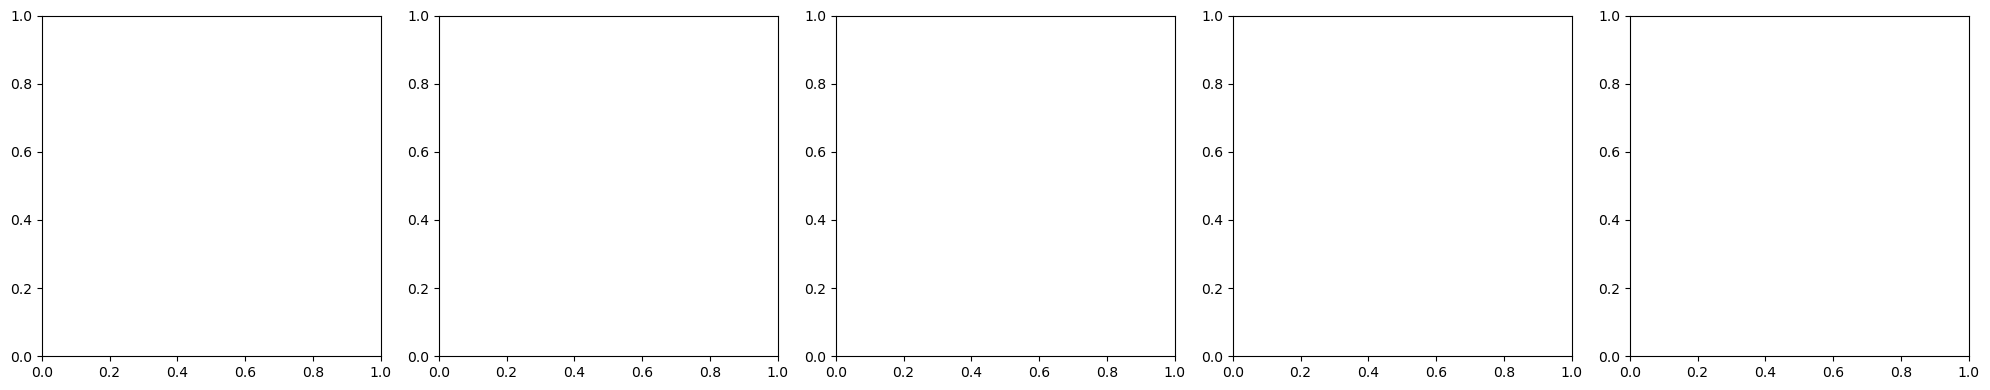

In [9]:
perplexities = [5, 15, 30, 50, 100]
fig, axes = plt.subplots(1, 5, figsize=(20, 4))

for i, perp in enumerate(perplexities):
    # YOUR CODE HERE
    # 1. Fit TSNE(n_components=2, perplexity=perp, random_state=42)
    # 2. Transform X_digits_scaled
    # 3. Scatter plot on axes[i], colored by y_digits
    # 4. Set title to f'perplexity={perp}'
    pass

plt.tight_layout()
plt.show()

### ✏️ Exercise 3.2: Reflection

Based on your perplexity exploration:

(a) What happens at **very low** perplexity (e.g., 5)?

(b) What happens at **very high** perplexity (e.g., 100)?

(c) Why is there no single "right" answer for perplexity?

*Your answer here:*



### ✏️ Exercise 3.3: The distortion warning

t-SNE can create **apparent clusters even in random data**. The cell below applies t-SNE to 500 points drawn from a uniform distribution — no clusters, no structure, just random noise.

Run it and answer: What do you see? What does this tell you about interpreting t-SNE plots?

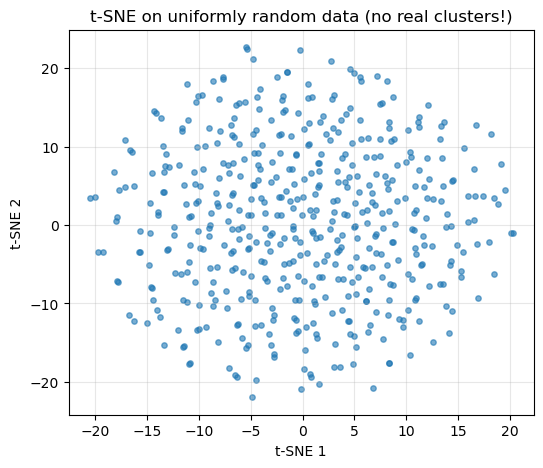

In [10]:
# t-SNE on completely random data (no structure)
np.random.seed(42)
random_data = np.random.uniform(size=(500, 50))

tsne_random = TSNE(n_components=2, perplexity=30, random_state=42)
random_2d = tsne_random.fit_transform(random_data)

plt.figure(figsize=(6, 5))
plt.scatter(random_2d[:, 0], random_2d[:, 1], s=15, alpha=0.6)
plt.title('t-SNE on uniformly random data (no real clusters!)')
plt.xlabel('t-SNE 1')
plt.ylabel('t-SNE 2')
plt.grid(True, alpha=0.3)
plt.show()

*Your reflection on the distortion warning:*



---
## Part 4: UMAP — Fast, and Preserves More Structure

UMAP (Uniform Manifold Approximation and Projection) works on similar principles to t-SNE — it preserves neighborhoods. But it has two practical advantages:

1. **It's much faster**, which matters when you have 10,000 neurons
2. **It preserves more global structure** — the relative positions of clusters tend to be more meaningful

The key parameter is `n_neighbors` (analogous to t-SNE's perplexity) and `min_dist` (how tightly packed points are).

OMP: Info #276: omp_set_nested routine deprecated, please use omp_set_max_active_levels instead.


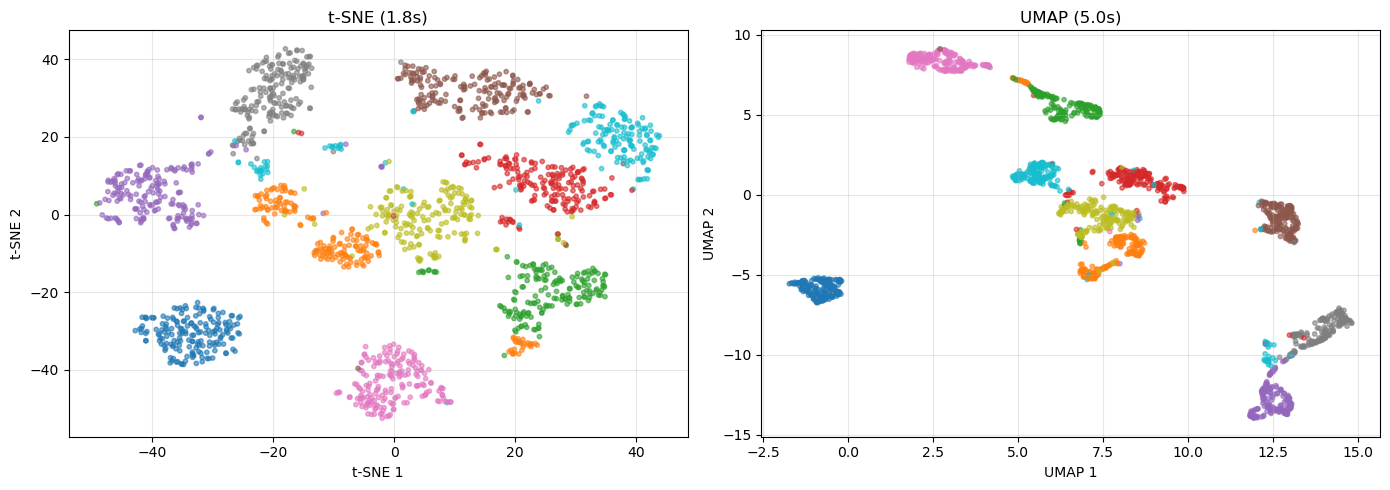

Speedup: UMAP was 0.4x faster than t-SNE


In [11]:
# UMAP vs t-SNE on digits, with timing
t0 = time.time()
tsne_result = TSNE(n_components=2, perplexity=30, random_state=42).fit_transform(X_digits_scaled)
t_tsne = time.time() - t0

t0 = time.time()
umap_result = umap.UMAP(n_neighbors=15, min_dist=0.1, random_state=42).fit_transform(X_digits_scaled)
t_umap = time.time() - t0

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].scatter(tsne_result[:, 0], tsne_result[:, 1], c=y_digits, cmap='tab10', s=10, alpha=0.6)
axes[0].set_title(f't-SNE ({t_tsne:.1f}s)')
axes[0].set_xlabel('t-SNE 1')
axes[0].set_ylabel('t-SNE 2')
axes[0].grid(True, alpha=0.3)

axes[1].scatter(umap_result[:, 0], umap_result[:, 1], c=y_digits, cmap='tab10', s=10, alpha=0.6)
axes[1].set_title(f'UMAP ({t_umap:.1f}s)')
axes[1].set_xlabel('UMAP 1')
axes[1].set_ylabel('UMAP 2')
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()
print(f'Speedup: UMAP was {t_tsne/t_umap:.1f}x faster than t-SNE')

Notice: (1) UMAP is faster. (2) The clusters are similarly well-separated. (3) The *relative positions* of clusters tend to be more meaningful in UMAP — digits that look similar (like 3, 5, and 8) often end up near each other.

### ✏️ Exercise 4.1: Exploring UMAP parameters

UMAP has two key parameters:
- `n_neighbors`: how local vs. global the embedding is (higher = more global)
- `min_dist`: how tightly packed the clusters are (lower = tighter)

Create a **3×3 grid** of UMAP plots varying `n_neighbors` in **[5, 15, 50]** and `min_dist` in **[0.0, 0.1, 0.5]**.

In [ ]:
n_neighbors_list = [5, 15, 50]
min_dist_list = [0.0, 0.1, 0.5]

fig, axes = plt.subplots(3, 3, figsize=(12, 12))

for i, nn in enumerate(n_neighbors_list):
    for j, md in enumerate(min_dist_list):
        # YOUR CODE HERE
        # 1. Fit umap.UMAP(n_neighbors=nn, min_dist=md, random_state=42)
        # 2. Transform X_digits_scaled
        # 3. Scatter plot on axes[i, j], colored by y_digits
        # 4. Set title to f'nn={nn}, md={md}'
        pass

plt.tight_layout()
plt.show()

### ✏️ Exercise 4.2: Reflection — Choosing a method

Compare your PCA, t-SNE, and UMAP visualizations of the digits dataset. In a few sentences, which method would you use if you wanted to:

(a) Do a **quick sanity check** of your data?

(b) Make a **publication figure** showing cluster structure?

(c) Use the reduced coordinates as **input to another algorithm** (like a classifier or clustering)?

*Your answer here:*



---
## Part 5: NMF — When the Parts Matter

PCA, t-SNE, and UMAP are great for *visualizing* structure, but the components they find aren't always easy to interpret. **NMF** (Non-negative Matrix Factorization) takes a different approach.

NMF is different from PCA in two key ways:
1. It only works on **non-negative data** (no negative values)
2. Both the components *and* the weights are constrained to be **non-negative**

This means NMF discovers **additive parts** — things that combine by adding up, never subtracting.

Think of it like **mixing paints**. NMF finds the base colors and how much of each color was mixed to make each sample. PCA, by contrast, might tell you to "add some blue and subtract some red" — which doesn't make physical sense for many data types.

This matters for neuroscience because many neural measurements are inherently non-negative:
- **Firing rates** can't be negative
- **Gene expression** levels can't be negative
- **Calcium fluorescence** can't go below zero

When you decompose this data with NMF, the components tend to correspond to recognizable biological *parts*.

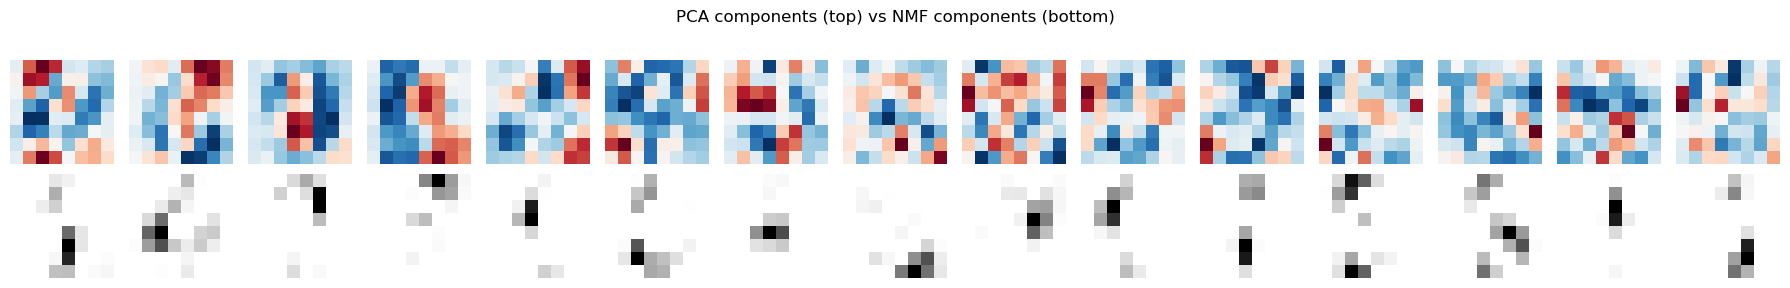

In [12]:
# NMF on digits: compare components to PCA
# NMF needs non-negative data, so we use MinMaxScaler
X_digits_nn = MinMaxScaler().fit_transform(X_digits)

n_comp = 15
nmf_digits = NMF(n_components=n_comp, random_state=42, max_iter=500)
W_digits = nmf_digits.fit_transform(X_digits_nn)  # weights
H_digits = nmf_digits.components_  # components

pca_digits_full = PCA(n_components=n_comp).fit(X_digits_scaled)

# Display the components as images
fig, axes = plt.subplots(2, n_comp, figsize=(18, 3))
for i in range(n_comp):
    axes[0, i].imshow(pca_digits_full.components_[i].reshape(8, 8), cmap='RdBu_r')
    axes[0, i].axis('off')
    if i == 0:
        axes[0, i].set_ylabel('PCA', fontsize=11, rotation=0, labelpad=30)

    axes[1, i].imshow(H_digits[i].reshape(8, 8), cmap='gray_r')
    axes[1, i].axis('off')
    if i == 0:
        axes[1, i].set_ylabel('NMF', fontsize=11, rotation=0, labelpad=30)

fig.suptitle('PCA components (top) vs NMF components (bottom)', fontsize=12)
plt.tight_layout()
plt.show()

See the difference? The **NMF components** look like actual pen strokes — a horizontal bar, a curve, a vertical line. Each digit is built by *adding* these parts together. The **PCA components** are holistic patterns with positive (red) and negative (blue) regions — harder to interpret as "parts."

Now let's apply NMF to real neuroscience data.

### NMF on Allen Brain Atlas Cell Types

The Allen Brain Atlas cell types dataset (which you may recognize from Lab 7) contains **electrophysiological features** measured from ~2,000 mouse neurons. Features include things like input resistance, firing rate adaptation, spike shape measurements — all non-negative quantities. This makes the data a natural fit for NMF.

Let's see if NMF can discover meaningful groupings of neurons based on their electrophysiological profiles.

Cell types data: 2333 neurons, 56 columns
After cleaning: 601 neurons, 56 features
Features: ['adaptation', 'avg_isi', 'electrode_0_pa', 'f_i_curve_slope', 'fast_trough_t_long_square'] ... ['upstroke_downstroke_ratio_short_square', 'vm_for_sag', 'vrest']


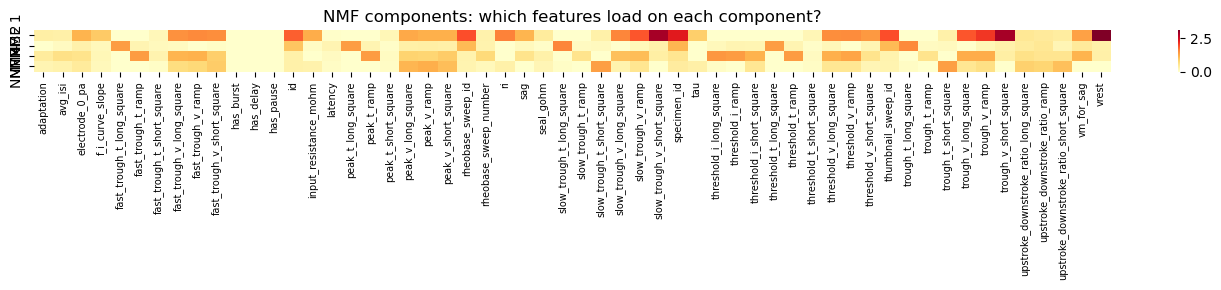


Top 5 features for each NMF component:
  NMF 1: ['vrest', 'slow_trough_v_short_square', 'trough_v_short_square', 'specimen_id', 'trough_v_ramp']
  NMF 2: ['slow_trough_t_long_square', 'trough_t_long_square', 'fast_trough_t_long_square', 'peak_t_long_square', 'threshold_t_long_square']
  NMF 3: ['threshold_i_long_square', 'peak_t_ramp', 'threshold_t_ramp', 'threshold_i_ramp', 'fast_trough_t_ramp']
  NMF 4: ['trough_t_short_square', 'slow_trough_t_short_square', 'peak_v_ramp', 'peak_v_long_square', 'peak_v_short_square']


In [13]:
# Load Allen cell types electrophysiology data
url_ct = "https://raw.githubusercontent.com/CastroLab/castro-teach-codebase/main/nspydcs357/cell_types/ephys_features.csv"
ct_df = pd.read_csv(url_ct)
print(f'Cell types data: {ct_df.shape[0]} neurons, {ct_df.shape[1]} columns')

# Drop any unnamed index column and rows with NaN
feature_cols = [c for c in ct_df.columns if not c.startswith('Unnamed')]
ct_df = ct_df[feature_cols].dropna()
print(f'After cleaning: {ct_df.shape[0]} neurons, {ct_df.shape[1]} features')
print(f'Features: {list(ct_df.columns[:5])} ... {list(ct_df.columns[-3:])}')

# Scale to [0, 1] for NMF
X_ct_nn = MinMaxScaler().fit_transform(ct_df)
X_ct_std = StandardScaler().fit_transform(ct_df)  # standardized version for PCA

# Fit NMF with 4 components
nmf_ct = NMF(n_components=4, random_state=42, max_iter=500)
W_ct = nmf_ct.fit_transform(X_ct_nn)  # neuron weights
H_ct = nmf_ct.components_  # feature loadings

# Heatmap of NMF components
fig, ax = plt.subplots(figsize=(14, 3))
sns.heatmap(H_ct, xticklabels=feature_cols, yticklabels=[f'NMF {i+1}' for i in range(4)],
            cmap='YlOrRd', ax=ax)
ax.set_title('NMF components: which features load on each component?')
plt.xticks(rotation=90, fontsize=7)
plt.tight_layout()
plt.show()

# Top features per component
print('\nTop 5 features for each NMF component:')
for i in range(4):
    top = np.argsort(H_ct[i])[::-1][:5]
    print(f'  NMF {i+1}: {[feature_cols[j] for j in top]}')

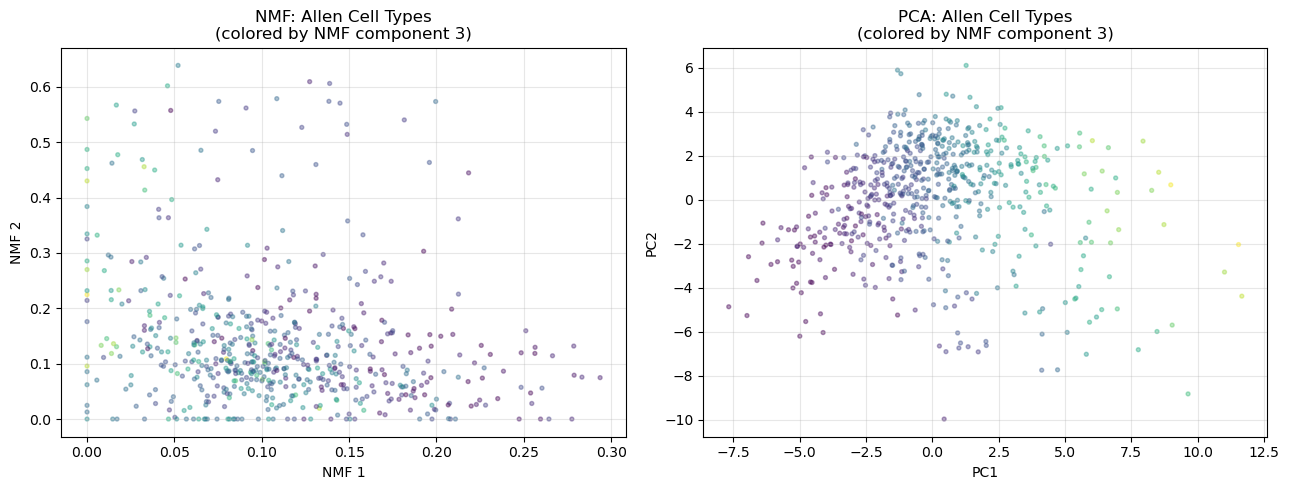

In [14]:
# Compare NMF vs PCA projections
pca_ct = PCA(n_components=2).fit_transform(X_ct_std)

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

axes[0].scatter(W_ct[:, 0], W_ct[:, 1], s=8, alpha=0.4, c=W_ct[:, 2], cmap='viridis')
axes[0].set_xlabel('NMF 1')
axes[0].set_ylabel('NMF 2')
axes[0].set_title('NMF: Allen Cell Types\n(colored by NMF component 3)')
axes[0].grid(True, alpha=0.3)

axes[1].scatter(pca_ct[:, 0], pca_ct[:, 1], s=8, alpha=0.4, c=W_ct[:, 2], cmap='viridis')
axes[1].set_xlabel('PC1')
axes[1].set_ylabel('PC2')
axes[1].set_title('PCA: Allen Cell Types\n(colored by NMF component 3)')
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

### ✏️ Exercise 5.1: Choosing k for NMF

NMF requires you to choose the number of components k. Fit NMF for k = 2, 3, 4, 5, 6, 8, 10. Plot the **reconstruction error** (`nmf.reconstruction_err_`) vs. k. Is there an "elbow"? How does this compare to the scree plot you made for PCA?

In [ ]:
# YOUR CODE HERE
k_values = [2, 3, 4, 5, 6, 8, 10]
errors = []

for k in k_values:
    # 1. Fit NMF(n_components=k, random_state=42, max_iter=500) on X_ct_nn
    # 2. Append nmf.reconstruction_err_ to errors
    pass

# 3. Plot errors vs k_values
# 4. Label axes and add a title


### ✏️ Exercise 5.2: Reflection

Look at the NMF component heatmap and the top features per component. Do the components seem to correspond to distinct *types* of neurons (e.g., fast-spiking vs. slow-spiking)? Compare the NMF 2D scatter with the PCA scatter — which reveals more structure?

*Your answer here:*



---
## Part 6: Neural Data — Real and Simulated

So far we've applied these methods to the Iris dataset, handwritten digits, and electrophysiological features. Now let's look at what dimensionality reduction reveals in **neural population recordings** — first with real data, then with a simulation where we know the ground truth.

### Real data: Stringer et al. (2019)

Stringer et al. recorded from ~10,000 neurons in mouse visual cortex using two-photon calcium imaging while the mouse was free to run on a treadmill. They found that even "spontaneous" neural activity (no stimulus presented) has a surprisingly low-dimensional structure — and much of it is explained by the mouse's own behavior (running speed, pupil dilation, facial movements).

Let's load a reduced version of this dataset and see what dimensionality reduction reveals.

In [15]:
# Load Stringer et al. data
url_stringer = "https://raw.githubusercontent.com/CastroLab/castro-teach-codebase/main/nspydcs357/projects/06_stringer_10k/data/stringer_reduced.csv"
stringer_df = pd.read_csv(url_stringer)
print(f'Stringer data: {stringer_df.shape}')

# Separate the pre-computed PCs, behavioral variables, and neuron traces
pc_cols = [c for c in stringer_df.columns if c.startswith('PC')]
behavior_cols = ['run_speed', 'pupil_area', 'face_motion']
neuron_cols = [c for c in stringer_df.columns if c.startswith('neuron_')]

print(f'Pre-computed PCs: {len(pc_cols)}')
print(f'Behavioral variables: {behavior_cols}')
print(f'Sampled neuron traces: {len(neuron_cols)}')

Stringer data: (2627, 73)
Pre-computed PCs: 20
Behavioral variables: ['run_speed', 'pupil_area', 'face_motion']
Sampled neuron traces: 50


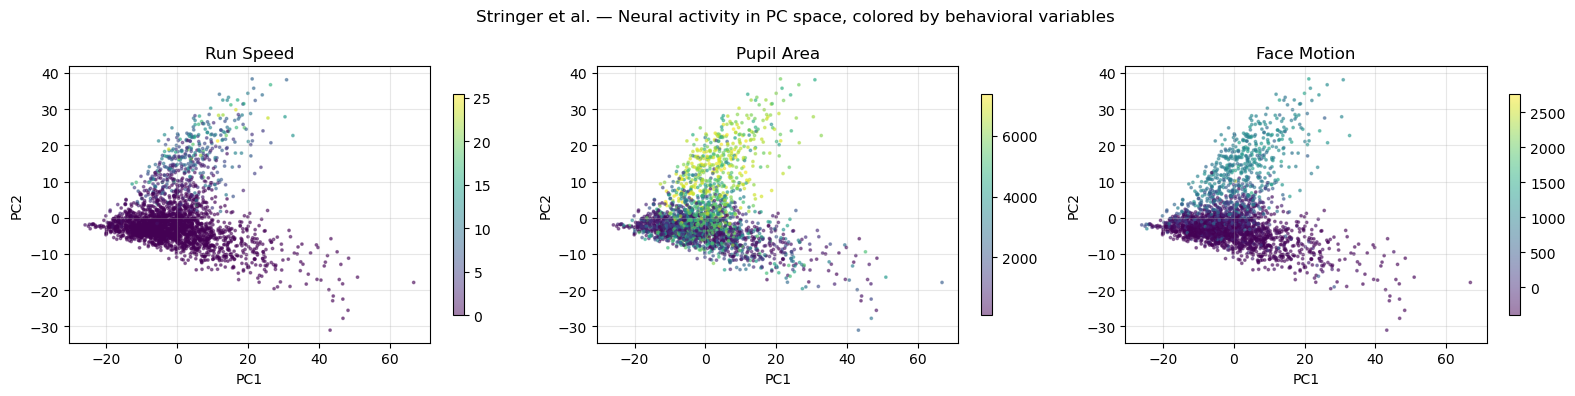

In [16]:
# Visualize the neural population in PC space, colored by behavior
fig, axes = plt.subplots(1, 3, figsize=(16, 4))

for i, bvar in enumerate(behavior_cols):
    sc = axes[i].scatter(stringer_df['PC1'], stringer_df['PC2'],
                         c=stringer_df[bvar], cmap='viridis', s=3, alpha=0.5)
    axes[i].set_xlabel('PC1')
    axes[i].set_ylabel('PC2')
    axes[i].set_title(bvar.replace('_', ' ').title())
    plt.colorbar(sc, ax=axes[i], shrink=0.8)
    axes[i].grid(True, alpha=0.3)

fig.suptitle('Stringer et al. — Neural activity in PC space, colored by behavioral variables', fontsize=12)
plt.tight_layout()
plt.show()

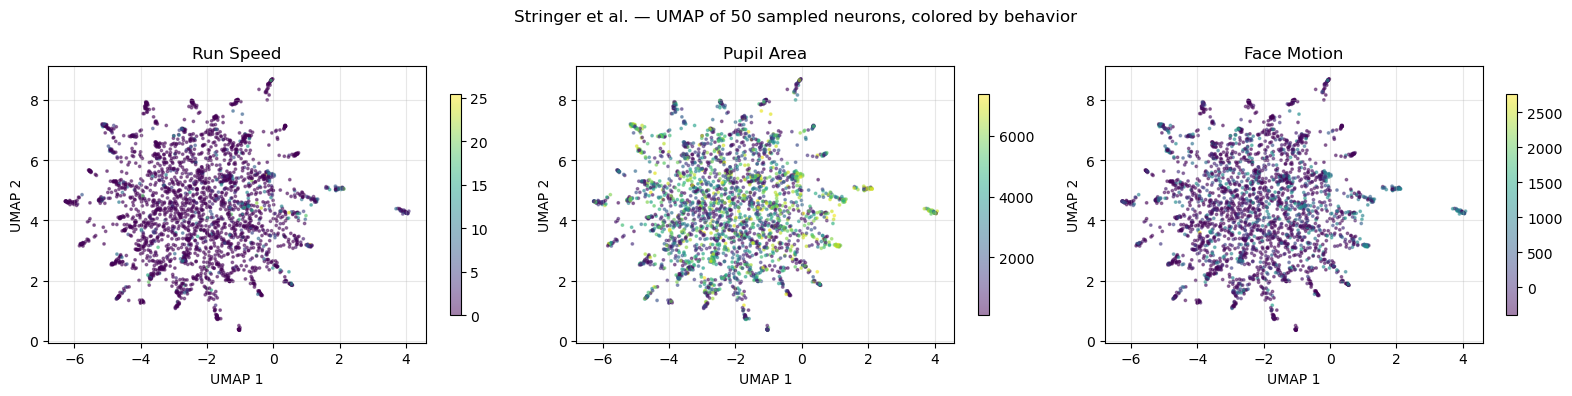

In [17]:
# UMAP on the sampled neurons, colored by running speed
X_stringer = stringer_df[neuron_cols].values
X_stringer_scaled = StandardScaler().fit_transform(X_stringer)

umap_stringer = umap.UMAP(n_neighbors=15, min_dist=0.1, random_state=42)
stringer_umap = umap_stringer.fit_transform(X_stringer_scaled)

fig, axes = plt.subplots(1, 3, figsize=(16, 4))
for i, bvar in enumerate(behavior_cols):
    sc = axes[i].scatter(stringer_umap[:, 0], stringer_umap[:, 1],
                         c=stringer_df[bvar], cmap='viridis', s=3, alpha=0.5)
    axes[i].set_xlabel('UMAP 1')
    axes[i].set_ylabel('UMAP 2')
    axes[i].set_title(bvar.replace('_', ' ').title())
    plt.colorbar(sc, ax=axes[i], shrink=0.8)
    axes[i].grid(True, alpha=0.3)

fig.suptitle('Stringer et al. — UMAP of 50 sampled neurons, colored by behavior', fontsize=12)
plt.tight_layout()
plt.show()

Even in "spontaneous" activity — no stimulus, just a mouse sitting there — the population activity has clear low-dimensional structure. And much of that structure correlates with behavior: running speed, pupil size, facial movements. This is one of the key findings of modern systems neuroscience: neural activity is low-dimensional and tightly linked to behavior.

But with real data, we never know the *true* latent structure. How do we know our methods are recovering the right thing? Let's build a simulation where we **do** know the answer.

### Simulated calcium imaging: the ground truth test

Imagine you're recording calcium signals from **200 neurons** in a mouse navigating a virtual environment. The mouse's behavior can be described by just **3 variables**: running speed, head direction, and the brightness of a visual stimulus.

Each neuron responds to some combination of these 3 latent variables, plus noise. So the "true" dimensionality is **3**, even though you're recording 200 neurons.

We're going to simulate this, then see which methods can recover the 3 latent dimensions.

In [18]:
# Simulate calcium imaging data with known latent structure
np.random.seed(357)
n_timepoints = 1000
n_neurons = 200

# Ground truth: 3 latent variables
t = np.linspace(0, 4 * np.pi, n_timepoints)
running_speed = np.abs(np.sin(t)) * 5 + np.random.normal(0, 0.3, n_timepoints)
head_direction = np.sin(t * 0.7) * 180
visual_stimulus = np.maximum(0, np.cos(t * 1.3) * 3 + np.random.normal(0, 0.2, n_timepoints))

latent = np.column_stack([running_speed, head_direction, visual_stimulus])  # (1000, 3)

# Each neuron is a random non-negative mixture of the latent variables + noise
mixing_weights = np.abs(np.random.randn(3, n_neurons))  # (3, 200)
calcium = np.maximum(0, latent @ mixing_weights + np.random.randn(n_timepoints, n_neurons) * 0.5)

print(f'Calcium data: {calcium.shape} (timepoints x neurons)')
print(f'Latent variables: {latent.shape} (timepoints x 3)')

Calcium data: (1000, 200) (timepoints x neurons)
Latent variables: (1000, 3) (timepoints x 3)


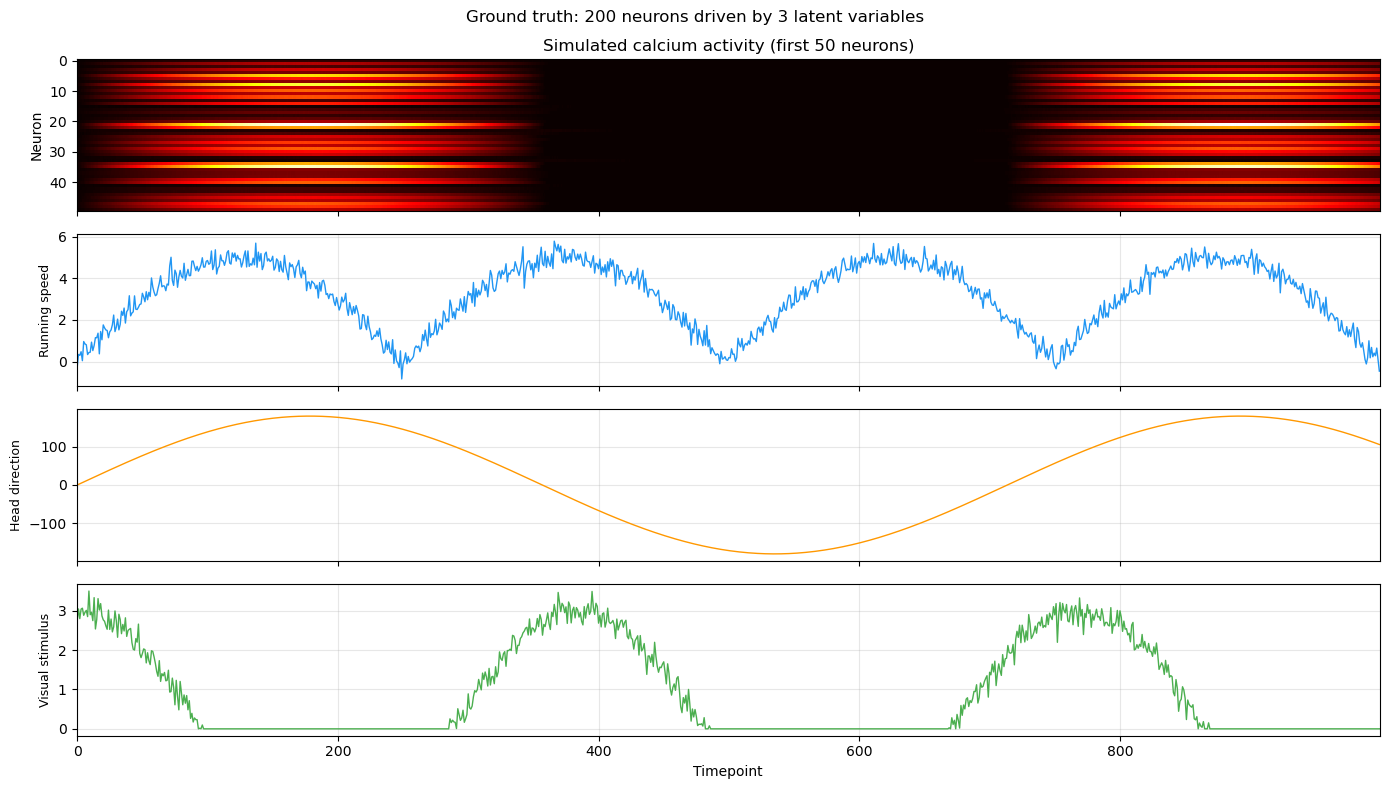

In [19]:
# Visualize the raw data and ground truth
fig, axes = plt.subplots(4, 1, figsize=(14, 8), sharex=True)

# Heatmap of calcium activity (first 50 neurons for clarity)
axes[0].imshow(calcium[:, :50].T, aspect='auto', cmap='hot', interpolation='nearest')
axes[0].set_ylabel('Neuron')
axes[0].set_title('Simulated calcium activity (first 50 neurons)')

# Ground truth latent variables
latent_names = ['Running speed', 'Head direction', 'Visual stimulus']
colors = ['#2196F3', '#FF9800', '#4CAF50']
for i in range(3):
    axes[i+1].plot(latent[:, i], color=colors[i], lw=1)
    axes[i+1].set_ylabel(latent_names[i], fontsize=9)
    axes[i+1].grid(True, alpha=0.3)

axes[3].set_xlabel('Timepoint')
fig.suptitle('Ground truth: 200 neurons driven by 3 latent variables', fontsize=12)
plt.tight_layout()
plt.show()

You can see the structure in the heatmap — waves of coordinated activity that mirror the latent variables below. Now let's see if dimensionality reduction can recover this structure *without* knowing the answer.

### ✏️ Exercise 6.1: PCA on the simulated data

Apply PCA to the calcium data.

(a) Make a **scree plot** (bar chart of `explained_variance_ratio_` for the first 10 components). How many PCs have notably high variance? Does this match the true dimensionality of 3?

(b) Plot **PC1 vs. running_speed**, **PC2 vs. head_direction**, and **PC3 vs. visual_stimulus** as scatter plots. Compute the Pearson correlation for each pair. Can PCA recover the latent variables?

(Hint: the order might not match perfectly — if PC1 doesn't correlate with running_speed, try other pairings.)

In [ ]:
# YOUR CODE HERE
# 1. Standardize the calcium data
# 2. Fit PCA(n_components=10)
# 3. Scree plot (bar chart of explained_variance_ratio_)

# 4. Scatter plots of first 3 PCs vs. latent variables
#    Use np.corrcoef(pc, latent_var)[0, 1] for correlation


### ✏️ Exercise 6.2: NMF on the simulated data

The calcium data is non-negative (fluorescence can't go below zero), so NMF is a natural choice.

Apply `NMF(n_components=3)` to the calcium data (use `MinMaxScaler` first). Plot each NMF component over time alongside the corresponding latent variable.

(The order of NMF components may not match the order of latent variables — you may need to try different pairings.)

In [ ]:
# YOUR CODE HERE
# 1. Scale calcium data with MinMaxScaler
# 2. Fit NMF(n_components=3, random_state=42, max_iter=500)
# 3. Get the weights W (timepoints x 3)
# 4. Plot each NMF component over time alongside each latent variable
#    (use subplots, overlay or side-by-side)
# 5. Compute correlations to find the best pairing


### ✏️ Exercise 6.3: t-SNE and UMAP on the simulated data

Apply both t-SNE and UMAP to the calcium data. Color the points by **running_speed**. Do the embeddings reveal meaningful structure?

In [ ]:
# YOUR CODE HERE
# 1. Standardize the calcium data
# 2. Fit TSNE and UMAP
# 3. Make 1x2 scatter plots, colored by running_speed


### ✏️ Exercise 6.4: Reflection

Which method best recovered the true 3D latent structure in the simulated data? For each method (PCA, NMF, t-SNE, UMAP), describe one **strength** and one **limitation** you observed in this exercise.

*Your answer here:*



In real neuroscience, you never know the ground truth. But exercises like this build your intuition:
- **PCA** will find the right *dimensionality* (the scree plot has an elbow at 3)
- **NMF** can recover *interpretable* non-negative components
- **t-SNE/UMAP** produce useful *visualizations* but don't directly tell you the dimensionality

---
## Part 7: Full Circle — Reduce, Then Cluster

In Lab 7, you learned about k-means and hierarchical clustering. A common workflow in neuroscience is to first reduce dimensionality, *then* cluster in the reduced space.

Why? Because clustering in 200 dimensions is noisy and slow. Many of those dimensions are just noise. Clustering in 3–10 dimensions (after PCA) is cleaner and faster — you've stripped away the noise and kept the signal.

Remember when we used PCA just to *visualize* our clusters? Now let's use it as a **preprocessing step** that actually improves clustering.

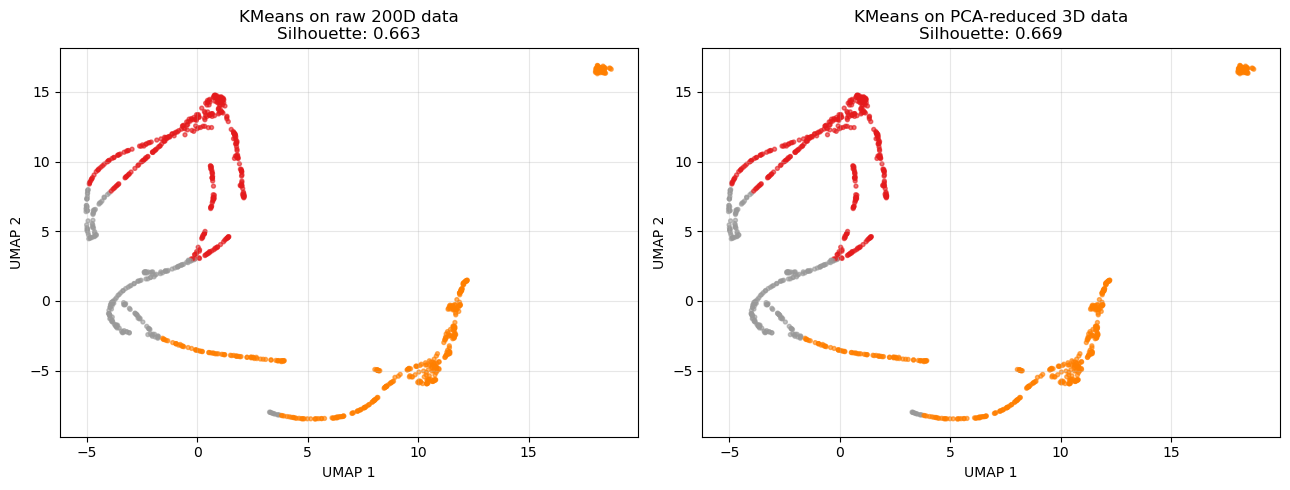

Silhouette score — Raw: 0.663 | PCA-reduced: 0.669


In [20]:
# Compare clustering in raw 200D space vs. PCA-reduced 3D space
calcium_scaled = StandardScaler().fit_transform(calcium)
calcium_pca_3d = PCA(n_components=3).fit_transform(calcium_scaled)

# KMeans on raw data
km_raw = KMeans(n_clusters=3, random_state=42, n_init=10).fit(calcium_scaled)
sil_raw = silhouette_score(calcium_scaled, km_raw.labels_)

# KMeans on PCA-reduced data
km_pca = KMeans(n_clusters=3, random_state=42, n_init=10).fit(calcium_pca_3d)
sil_pca = silhouette_score(calcium_pca_3d, km_pca.labels_)

# Visualize with UMAP
calcium_umap = umap.UMAP(n_neighbors=15, min_dist=0.1, random_state=42).fit_transform(calcium_scaled)

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
axes[0].scatter(calcium_umap[:, 0], calcium_umap[:, 1], c=km_raw.labels_, cmap='Set1', s=8, alpha=0.6)
axes[0].set_title(f'KMeans on raw 200D data\nSilhouette: {sil_raw:.3f}')
axes[0].set_xlabel('UMAP 1')
axes[0].set_ylabel('UMAP 2')
axes[0].grid(True, alpha=0.3)

axes[1].scatter(calcium_umap[:, 0], calcium_umap[:, 1], c=km_pca.labels_, cmap='Set1', s=8, alpha=0.6)
axes[1].set_title(f'KMeans on PCA-reduced 3D data\nSilhouette: {sil_pca:.3f}')
axes[1].set_xlabel('UMAP 1')
axes[1].set_ylabel('UMAP 2')
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()
print(f'Silhouette score — Raw: {sil_raw:.3f} | PCA-reduced: {sil_pca:.3f}')

### ✏️ Exercise 7.1: Reduce-then-cluster on Allen cell types

Apply the reduce-then-cluster pipeline to the Allen cell types dataset:

1. Reduce to **5 PCs** using PCA on `X_ct_std`
2. Run **KMeans with k=3** on the reduced data
3. Visualize the clusters using UMAP, colored by cluster label
4. Compare the silhouette score of clustering in the full space vs. PCA-reduced space

(Hint: you can reuse patterns from the simulated data example above.)

In [ ]:
# YOUR CODE HERE
# 1. PCA(n_components=5) on X_ct_std
# 2. KMeans(n_clusters=3, random_state=42) on PCA-reduced data
# 3. Also KMeans on raw X_ct_std for comparison
# 4. Compute silhouette scores for both
# 5. Visualize with UMAP


### ✏️ Exercise 7.2: Reflection

Why might reducing dimensions before clustering give better results than clustering the raw high-dimensional data? Give both a **statistical reason** and a **computational reason**.

*Your answer here:*



### ✏️ Exercise 7.3: Method comparison

Fill in this table summarizing what you've learned about each dimensionality reduction method.

| Method | Linear or nonlinear? | Preserves global or local structure? | Interpretable components? | When would you use it? |
|--------|---------------------|--------------------------------------|--------------------------|------------------------|
| PCA    |                     |                                      |                          |                        |
| t-SNE  |                     |                                      |                          |                        |
| UMAP   |                     |                                      |                          |                        |
| NMF    |                     |                                      |                          |                        |

*Your completed table here:*

| Method | Linear or nonlinear? | Preserves global or local structure? | Interpretable components? | When would you use it? |
|--------|---------------------|--------------------------------------|--------------------------|------------------------|
| PCA    |                     |                                      |                          |                        |
| t-SNE  |                     |                                      |                          |                        |
| UMAP   |                     |                                      |                          |                        |
| NMF    |                     |                                      |                          |                        |

---
## Wrap-Up

Today you learned four ways to reduce high-dimensional data to its essentials:

- **PCA** finds the linear directions of greatest variance — fast, deterministic, and gives you a scree plot to estimate dimensionality
- **t-SNE** preserves local neighborhoods to reveal cluster structure — powerful but slow, and the output can be misleading if you're not careful
- **UMAP** is similar to t-SNE but faster and better at preserving global relationships
- **NMF** decomposes non-negative data into additive parts — uniquely interpretable for neural data types like firing rates and calcium traces

The key insight from the simulated calcium imaging exercise: when 95% of the variance in 200 neurons is captured by 3 components, that tells you something profound — the brain is using a much **lower-dimensional** representation than the raw data suggests. Finding that representation is one of the central goals of computational neuroscience.

These methods will keep coming back in later labs and in your final projects. Dimensionality reduction is rarely the end goal — it's a **critical preprocessing step** that makes everything else (visualization, clustering, classification, modeling) work better.

### Further Reading

- [How to Use t-SNE Effectively](https://distill.pub/2016/misread-tsne/) — Wattenberg, Viégas & Johnson (2016). Essential reading on t-SNE pitfalls.
- [Stringer et al. (2019)](https://doi.org/10.1126/science.aav7893) — "Spontaneous behaviors drive multidimensional, brainwide activity." *Science*.
- [Cunningham & Yu (2014)](https://doi.org/10.1038/nn.3776) — "Dimensionality reduction for large-scale neural recordings." *Nature Neuroscience*.
- [UMAP documentation](https://umap-learn.readthedocs.io/) — Includes great explanations of how UMAP works and parameter tuning.